In [63]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [64]:
df = pd.read_csv("creditcard.csv")

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [66]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [67]:
df.describe

<bound method NDFrame.describe of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599

Fraud case: 492
Valid case: 284315
Percentage of fraud account 0.0017


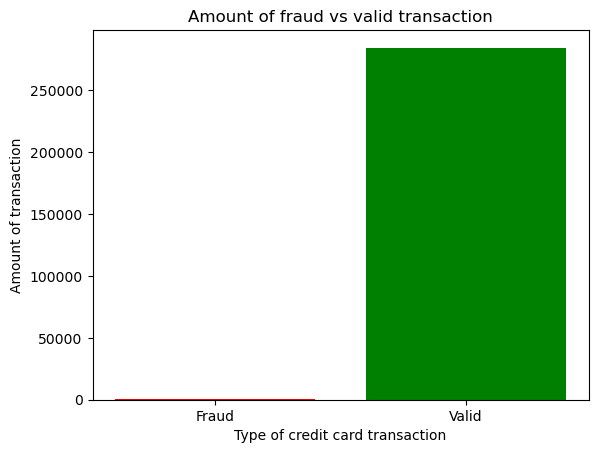

In [68]:
fraud = df[df["Class"]==1]['Class'].count()
valid = df[df["Class"]==0]['Class'].count()
print(f"Fraud case: {fraud}")
print(f"Valid case: {valid}")
print(f"Percentage of fraud account {round(fraud/(fraud+valid),4)}")
plt.bar(['Fraud','Valid'],[fraud,valid],color=['red','green'])
plt.xlabel("Type of credit card transaction")
plt.ylabel("Amount of transaction")
plt.title("Amount of fraud vs valid transaction")
plt.show()

From that bar chart we see that this dataset is imbalance 

In [69]:
df_valid = df[df["Class"]==0]

In [70]:
df_fraud = df[df["Class"]==1]

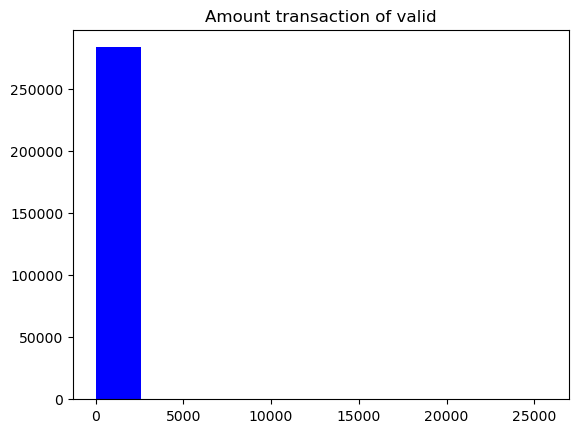

In [71]:
plt.hist(df_valid["Amount"],color="Blue")
plt.title("Amount transaction of valid")
plt.show()

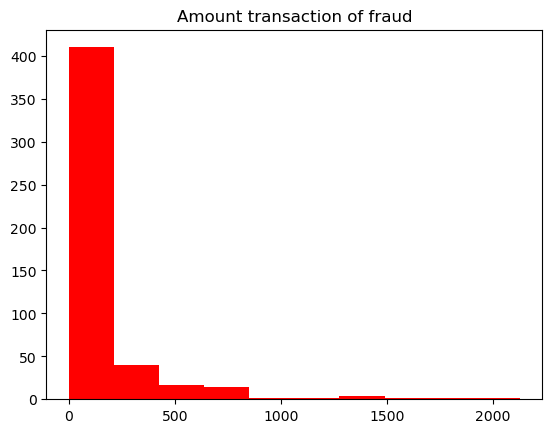

In [72]:
plt.hist(df_fraud["Amount"],color="red")
plt.title("Amount transaction of fraud")
plt.show()

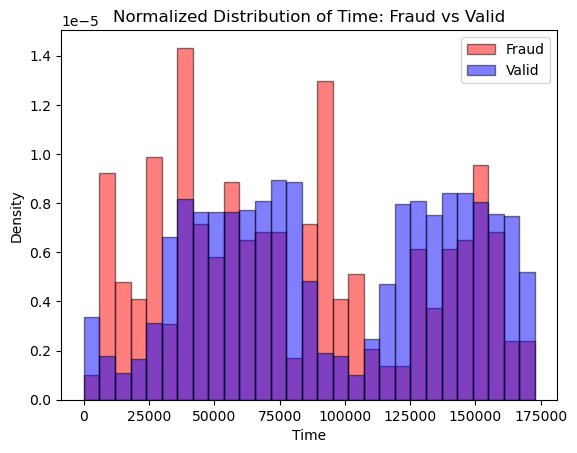

In [73]:
import matplotlib.pyplot as plt
import numpy as np


bins = np.linspace(min(df_valid["Time"].min(), df_fraud["Time"].min()), 
                   max(df_valid["Time"].max(), df_fraud["Time"].max()), 
                   30) 

plt.hist(df_fraud["Time"], bins=bins, alpha=0.5, label='Fraud', density=True, color='red', edgecolor='black')
plt.hist(df_valid["Time"], bins=bins, alpha=0.5, label='Valid', density=True, color='blue', edgecolor='black')

plt.title("Normalized Distribution of Time: Fraud vs Valid")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend(loc='upper right')
plt.show()

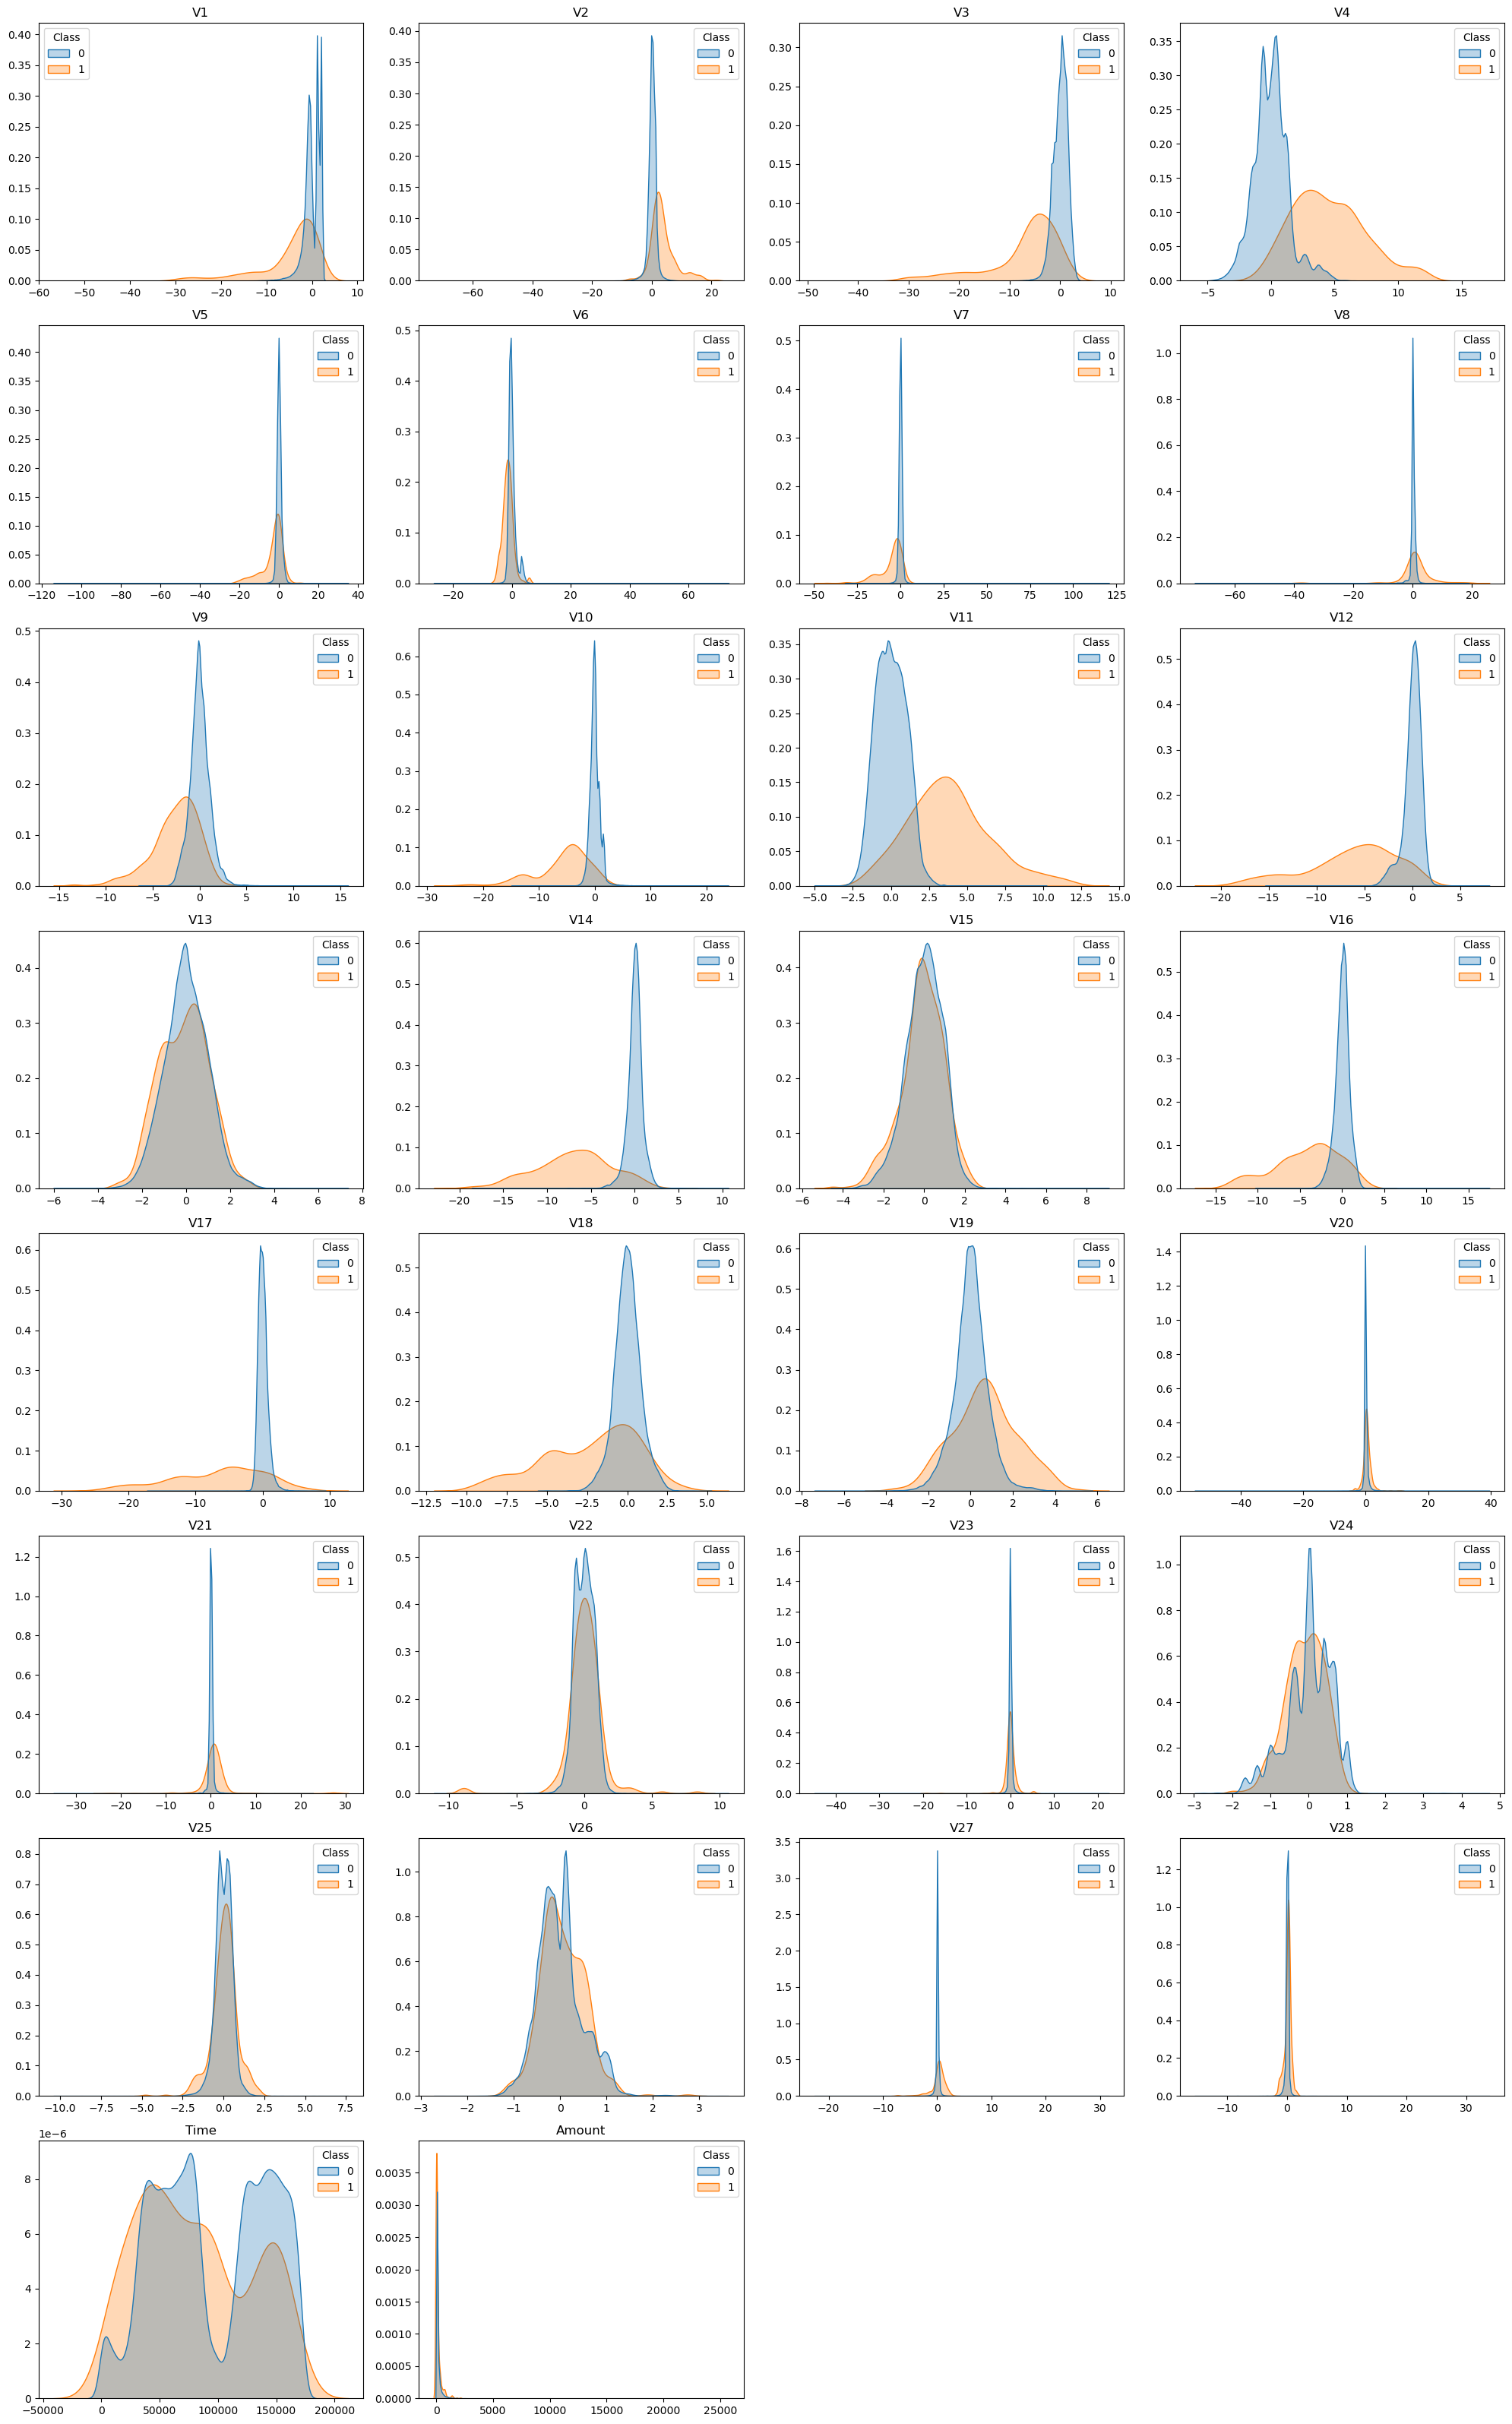

In [74]:
def analyze_feature_distributions(df, features, target='Class'):
    
    n_cols = 4
    n_rows = math.ceil(len(features) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.kdeplot(
            data=df, 
            x=col, 
            hue=target, 
            fill=True, 
            common_norm=False, 
            palette=['#1f77b4', '#ff7f0e'], 
            alpha=0.3, 
            ax=axes[i],
            warn_singular=False
        )
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    
    for i in range(len(features), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

v_features = [f'V{i}' for i in range(1, 29)]
v_features.append('Time')
v_features.append('Amount')
analyze_feature_distributions(df, v_features)

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


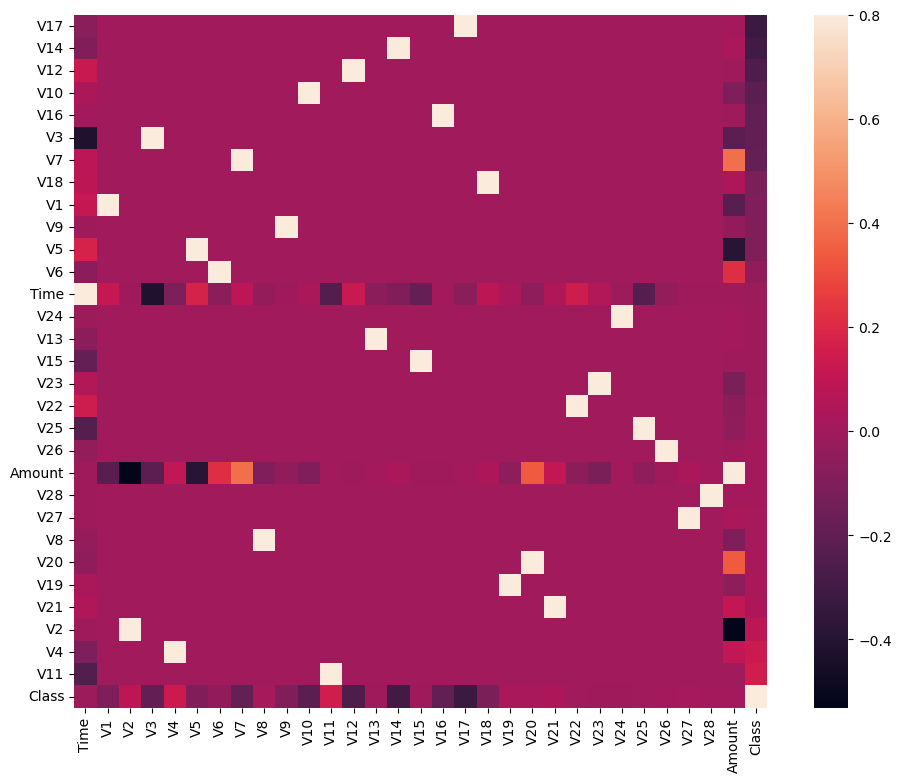

In [75]:
corrmat = df.corr()
corrmat = corrmat.sort_values(by="Class")
print(corrmat["Class"].head(5))
print(corrmat["Class"].tail(6))
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [76]:
feature_selection = [17,12,10,16,19,21,2,4,11,1,3,14,18,9]

In [77]:
feature  = []

for i in feature_selection:
    feature.append("V"+str(i))
print(feature)

df_selection = df[feature]
df_selection["Time"] = df["Time"]
df_selection['Amount'] = df["Amount"]
df_selection['Class'] = df['Class']
df_selection.head()

['V17', 'V12', 'V10', 'V16', 'V19', 'V21', 'V2', 'V4', 'V11', 'V1', 'V3', 'V14', 'V18', 'V9']


/tmp/ipykernel_10697/2614839763.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection["Time"] = df["Time"]
/tmp/ipykernel_10697/2614839763.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection['Amount'] = df["Amount"]
/tmp/ipykernel_10697/2614839763.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

,V17,V12,V10,V16,V19,V21,V2,V4,V11,V1,V3,V14,V18,V9,Time,Amount,Class
0,0.207971,-0.617801,0.090794,-0.470401,0.403993,-0.018307,-0.072781,1.378155,-0.551600,-1.359807,2.536347,-0.311169,0.025791,0.363787,0.0,149.62,0
1,-0.114805,1.065235,-0.166974,0.463917,-0.145783,-0.225775,0.266151,0.448154,1.612727,1.191857,0.166480,-0.143772,-0.183361,-0.255425,0.0,2.69,0
2,1.109969,0.066084,0.207643,-2.890083,-2.261857,0.247998,-1.340163,0.379780,0.624501,-1.358354,1.773209,-0.165946,-0.121359,-1.514654,1.0,378.66,0
3,-0.684093,0.178228,-0.054952,-1.059647,-1.232622,-0.108300,-0.185226,-0.863291,-0.226487,-0.966272,1.792993,-0.287924,1.965775,-1.387024,1.0,123.50,0
4,-0.237033,0.538196,0.753074,-0.451449,0.803487,-0.009431,0.877737,0.403034,-0.822843,-1.158233,1.548718,-1.119670,-0.038195,0.817739,2.0,69.99,0


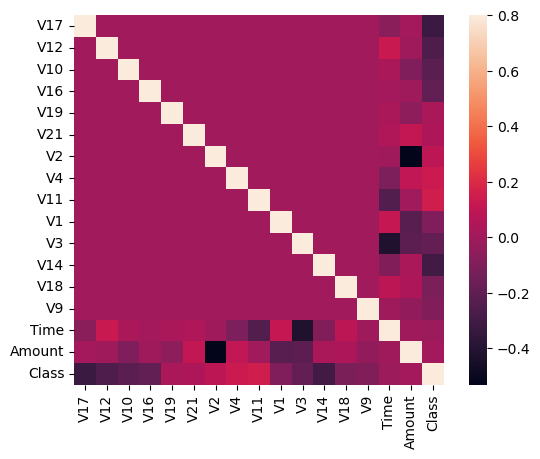

In [78]:
cor_selection = df_selection.corr()
sns.heatmap(cor_selection, vmax = .8, square = True)
plt.show()

In [79]:
df_selection.to_csv("Model_data_creditcard.csv")